In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = pd.read_csv('../Datasets/student_performance_updated_1000.csv')
data 

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [55]:
data.isnull().sum()

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

In [56]:
data.duplicated().sum()

np.int64(0)

In [57]:
data.dtypes

StudentID                    float64
Name                          object
Gender                        object
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport               object
FinalGrade                   float64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken          object
dtype: object

In [58]:
df = data.copy()

In [59]:
df['StudentID'] = df['StudentID'].fillna('Unknown')
df

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Unknown,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [60]:
df.isnull().sum()

StudentID                     0
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

In [61]:
target_columns =['Name', 'Gender', 'ParentalSupport', 'Online Classes Taken']
df[target_columns] = df[target_columns].fillna('Unknown')

In [62]:
df.isnull().sum()

StudentID                     0
Name                          0
Gender                        0
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport               0
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken          0
dtype: int64

In [63]:
df

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Unknown,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,Unknown,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [64]:
fill_with_mean = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'Study Hours', 'Attendance (%)', 'FinalGrade']

In [65]:
for col in fill_with_mean:
    mean_value = df[col].mean().round()
    df[col].fillna(mean_value, inplace=True)

df

C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6460\1200854422.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,86.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Unknown,Kenneth Murray,Male,85.0,20.0,78.0,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,18.0,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,Unknown,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [66]:
df.isnull().sum()

StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

In [67]:
df = df[df['Gender'] != 'Unknown']
df

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,86.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Unknown,Kenneth Murray,Male,85.0,20.0,78.0,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,18.0,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,Unknown,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [68]:
study_hour = df.groupby('Gender')['Study Hours'].mean().round(1).reset_index()
study_hour

,Gender,Study Hours
0,Female,2.3
1,Male,2.5


In [69]:
study_hour

,Gender,Study Hours
0,Female,2.3
1,Male,2.5


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6460\1204357790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = study_hour, x='Study Hours' , y = 'Gender' , palette='rocket')


<function matplotlib.pyplot.show(close=None, block=None)>

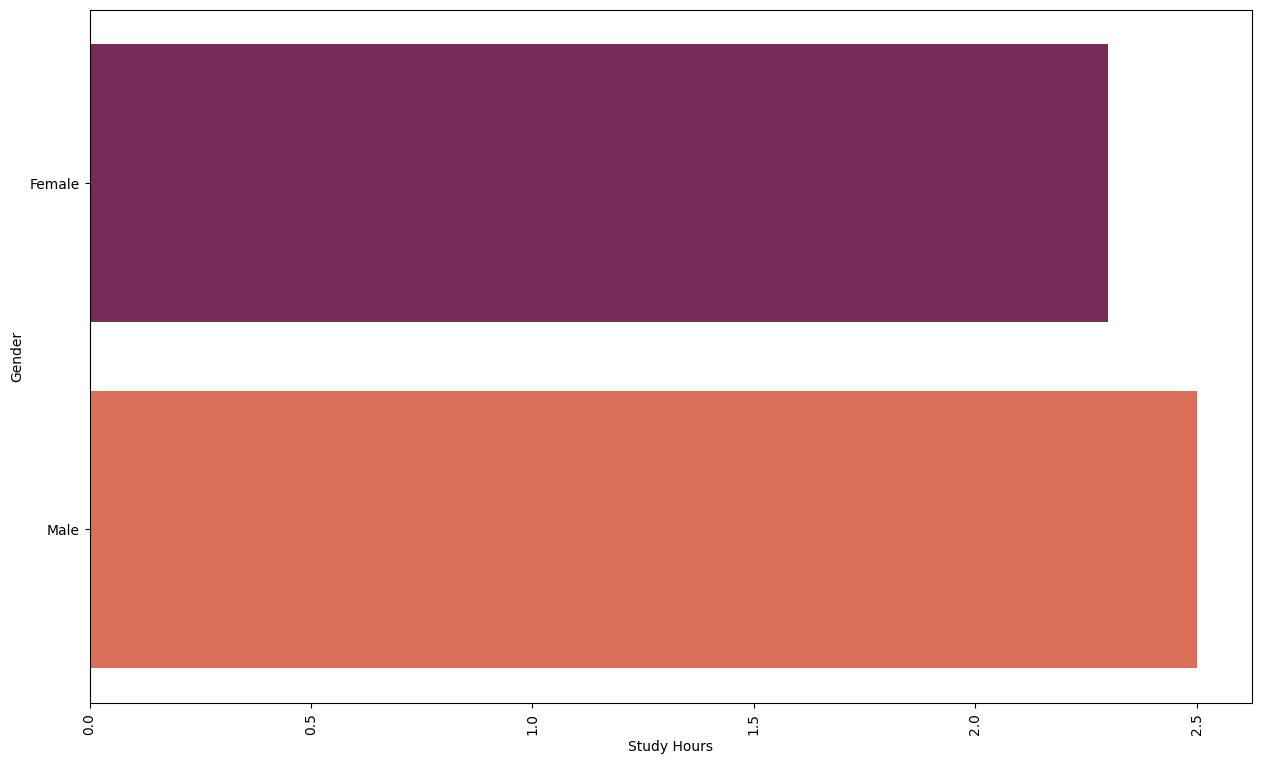

In [70]:
plt.figure(figsize=(15,9))
sns.barplot(data = study_hour, x='Study Hours' , y = 'Gender' , palette='rocket')
plt.xticks(rotation = 90)
plt.show

In [71]:
study_hour_week = df.groupby('Gender')['StudyHoursPerWeek'].mean().round(1).reset_index()
study_hour_week

,Gender,StudyHoursPerWeek
0,Female,17.7
1,Male,17.6


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6460\2533813400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = study_hour_week, x = 'StudyHoursPerWeek' , y = 'Gender', palette='rocket')


<function matplotlib.pyplot.show(close=None, block=None)>

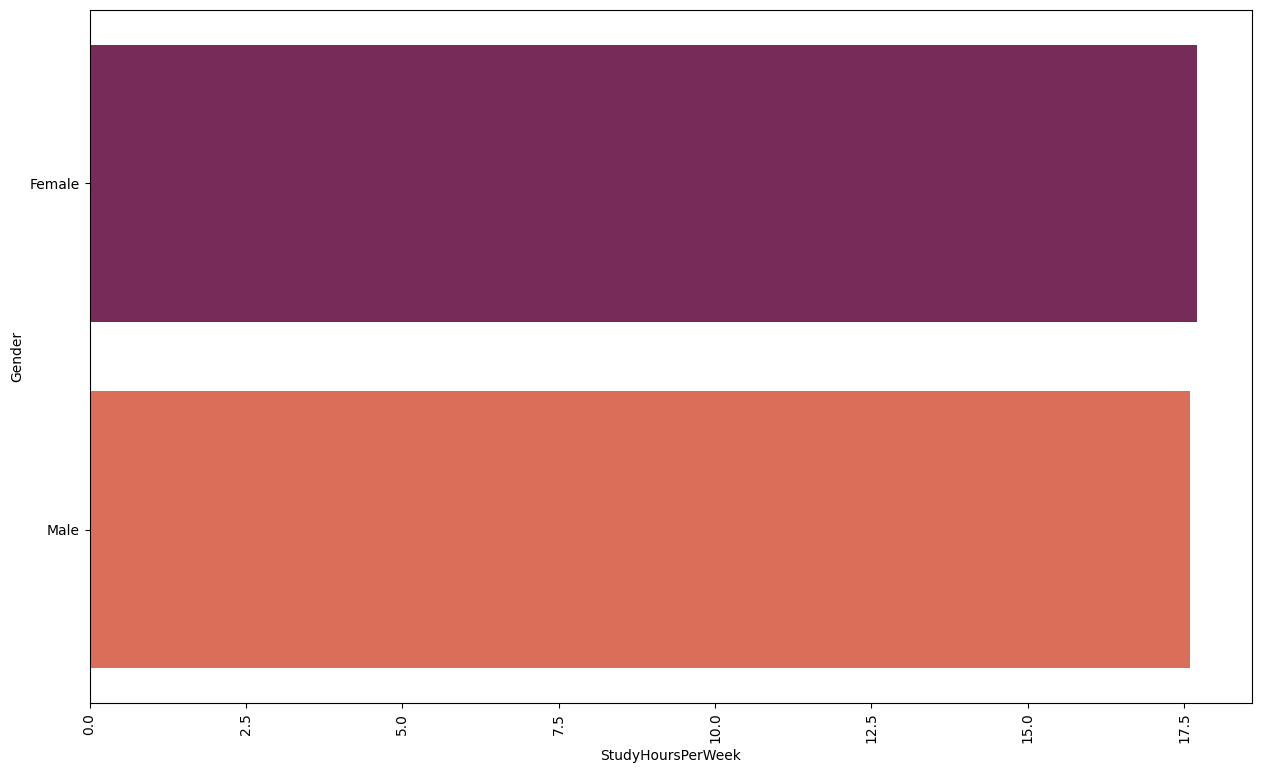

In [72]:
plt.figure(figsize=(15,9))
sns.barplot(data = study_hour_week, x = 'StudyHoursPerWeek' , y = 'Gender', palette='rocket')
plt.xticks(rotation = 90)
plt.show

In [73]:
final_grade = df.groupby('Gender')['FinalGrade'].mean().round(1).reset_index()
final_grade

,Gender,FinalGrade
0,Female,80.5
1,Male,79.8


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6460\2282450880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = final_grade , x= 'FinalGrade' , y = 'Gender' , palette='rocket')


<function matplotlib.pyplot.show(close=None, block=None)>

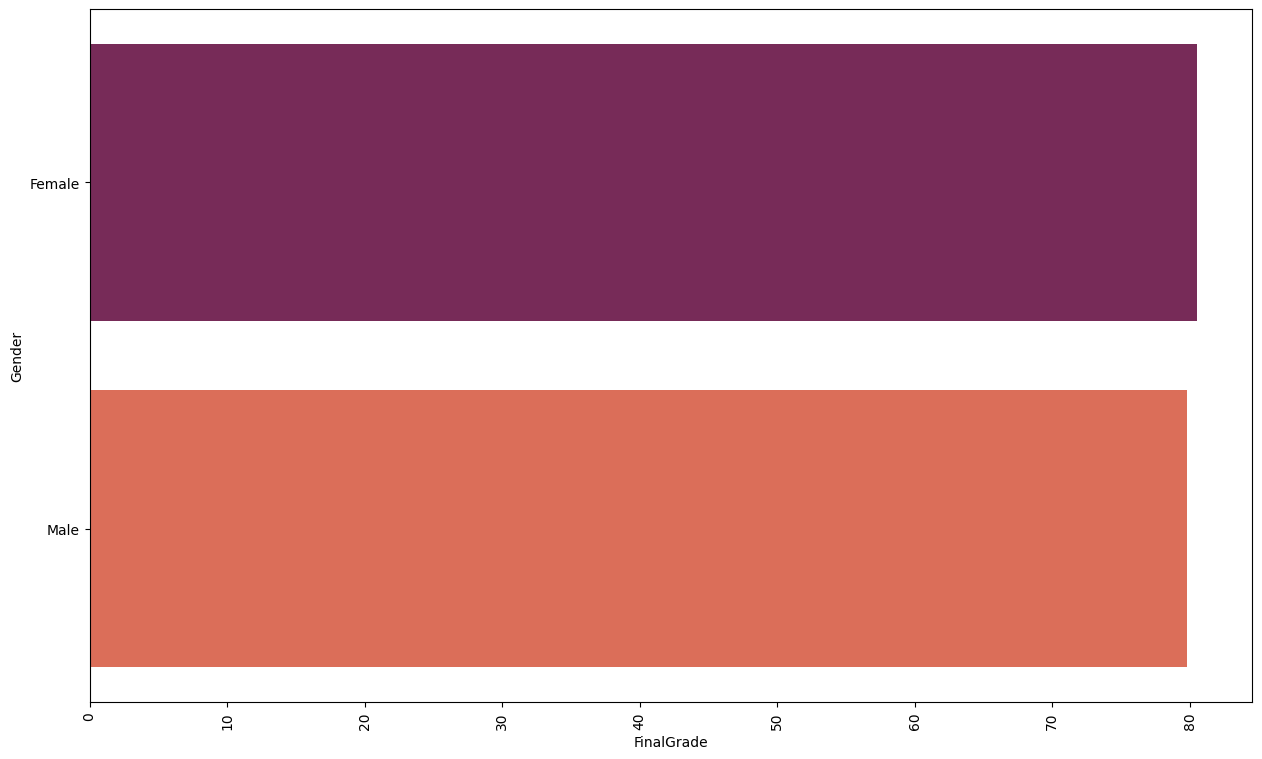

In [74]:
plt.figure(figsize=(15,9))
sns.barplot(data = final_grade , x= 'FinalGrade' , y = 'Gender' , palette='rocket')
plt.xticks(rotation = 90)
plt.show

In [75]:
df.to_csv('../Datasets/clean_student_performance_updated_1000.csv', index=False)